# Track A: Predicting Initial Hospital Admissions
Trained on **all 62,135 patients** to predict `Admitted_Yes_No`. Companion to Track B (`03_ML_Model_Readmission`), which conditions on admitted patients only. Leakage columns (`Readmitted_Yes_No`, `Num_Admissions`, `Avg_LOS`) are dropped in Step 1 — `Avg_LOS` only exists post-admission and cannot predict initial admission.

In [1]:
import pandas as pd
import numpy as np
import os
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# 1. Define Paths (portable — resolves repo root from this notebook's location,
#    overridable via PROJECT_D_BASE env var for CI / other machines)
base_path = os.environ.get(
    "PROJECT_D_BASE",
    str(pathlib.Path(os.getcwd()).resolve().parents[1])
)
input_file = os.path.join(base_path, "machineLearning", "csv", "ml_ready_dataset.csv")

# 2. Load the data
print(f"Loading dataset from: {input_file}")
df = pd.read_csv(input_file)

print(f"✅ ML dataset loaded successfully. Total shape: {df.shape}")

Loading dataset from: C:\Users\thira\Documents\GitHub\project-d\machineLearning\csv\ml_ready_dataset.csv
✅ ML dataset loaded successfully. Total shape: (61406, 26)


In [2]:
# 1. Define the target variable for Model Track A
target = 'Admitted_Yes_No'

# 2. Define columns that cause Data Leakage for this specific model
# You cannot use hospital stay length or readmission status to predict initial admission
leakage_cols = ['Readmitted_Yes_No', 'Num_Admissions', 'Avg_LOS']

# 3. Separate Features (X) and Target (y)
X = df.drop(columns=[target] + leakage_cols, errors='ignore')
y = df[target]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Display the raw class imbalance
print("\nReal-World Class Distribution (Admitted vs Not Admitted):")
print(y.value_counts(normalize=True) * 100)

Features (X) shape: (61406, 22)
Target (y) shape: (61406,)

Real-World Class Distribution (Admitted vs Not Admitted):
Admitted_Yes_No
0    87.038726
1    12.961274
Name: proportion, dtype: float64


In [3]:
# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set: {X_train.shape[0]} patients")
print(f"✅ Testing set: {X_test.shape[0]} patients")

✅ Training set: 49124 patients
✅ Testing set: 12282 patients


### Step 2: Smart Preprocessing and Scaling
Splits the 22 features into 5 continuous columns (standard-scaled) and 17 binary flags (passthrough) using a `ColumnTransformer`. Scaling only the continuous block keeps the 0/1 flags interpretable in SHAP later.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

print("--- STEP 1: SMART PREPROCESSING & SCALING ---")

# 1. Identify Continuous vs. Binary/Categorical columns
continuous_cols = [
    'AGE', 
    'Num_Visits', 
    'Total_Meds_Count', 
    'Total_Unique_Diagnoses', 
    'Severity_Encoded'
]

binary_cols = [col for col in X_train.columns if col not in continuous_cols]

print(f"Identified {len(continuous_cols)} continuous features to scale.")
print(f"Identified {len(binary_cols)} binary features to leave unscaled.\n")

# 2. Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat', 'passthrough', binary_cols)
    ])

# 3. Fit and Transform the data
X_train_processed_array = preprocessor.fit_transform(X_train)
X_test_processed_array = preprocessor.transform(X_test)

# 4. Reconstruct Pandas DataFrames
new_column_order = continuous_cols + binary_cols

X_train_final = pd.DataFrame(X_train_processed_array, columns=new_column_order, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed_array, columns=new_column_order, index=X_test.index)

print(f"✅ Final Training features shape: {X_train_final.shape}")
print(f"✅ Final Testing features shape: {X_test_final.shape}")
print("\nReady for Model Training!")


--- STEP 1: SMART PREPROCESSING & SCALING ---
Identified 5 continuous features to scale.
Identified 17 binary features to leave unscaled.

✅ Final Training features shape: (49124, 22)
✅ Final Testing features shape: (12282, 22)

Ready for Model Training!


### Step 3: Model Training and Hyperparameter Tuning
Trains three models (Logistic Regression, Random Forest, XGBoost) with stratified 3-fold CV scored on F1. LR uses `GridSearchCV` (small grid); RF and XGB use `RandomizedSearchCV` (`n_iter=10`). XGB handles the 1:6.77 class imbalance with `scale_pos_weight`; LR and RF use `class_weight='balanced'`.

In [5]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("--- PHASE 3: MODEL TRAINING & HYPERPARAMETER TUNING ---")

# Calculate the exact imbalance ratio for XGBoost later
negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
scale_weight = negative_cases / positive_cases

print(f"Dataset Imbalance Ratio: 1 Admission for every {scale_weight:.2f} Non-Admissions." + chr(10))

# Setup Cross-Validation strategy for all models
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- 1. Logistic Regression ---      
print("Training & Tuning Logistic Regression...")
start_time = time.time()

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': ['balanced']
}

lr_tuned = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid=lr_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)
lr_tuned.fit(X_train_final, y_train)
lr_model = lr_tuned.best_estimator_

print(f"✅ LR Tuned & Trained in {time.time() - start_time:.2f} seconds")
print(f"🏆 LR Best Parameters: {lr_tuned.best_params_}")



--- PHASE 3: MODEL TRAINING & HYPERPARAMETER TUNING ---
Dataset Imbalance Ratio: 1 Admission for every 6.72 Non-Admissions.

Training & Tuning Logistic Regression...


✅ LR Tuned & Trained in 5.33 seconds
🏆 LR Best Parameters: {'C': 1, 'class_weight': 'balanced', 'solver': 'liblinear'}


In [6]:
# --- 2. Random Forest ---    
print(chr(10) + "Training & Tuning Random Forest...")    
start_time = time.time()

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train_final, y_train)  
rf_model = rf_tuned.best_estimator_

print(f"✅ RF Tuned & Trained in {time.time() - start_time:.2f} seconds")
print(f"🏆 RF Best Parameters: {rf_tuned.best_params_}")




Training & Tuning Random Forest...


✅ RF Tuned & Trained in 14.86 seconds
🏆 RF Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 15, 'class_weight': 'balanced_subsample'}


In [7]:
# --- 3. XGBoost ---
print(chr(10) + "Training & Tuning XGBoost...")
start_time = time.time()

# Define Parameter Grid
xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Initialize RandomizedSearchCV
xgb_tuned = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring='f1', 
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Fit the tuner
xgb_tuned.fit(X_train_final, y_train)

# Extract the best model
xgb_model = xgb_tuned.best_estimator_

print(f"✅ XGBoost Tuned & Trained in {time.time() - start_time:.2f} seconds")
print(f"🏆 XGBoost Best Parameters: {xgb_tuned.best_params_}")




Training & Tuning XGBoost...


✅ XGBoost Tuned & Trained in 3.49 seconds
🏆 XGBoost Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


### Step 4: Evaluation and Threshold Optimisation
The F1-maximising classification threshold is learned on the **training set's** predicted probabilities and then applied unchanged to the held-out test set. This mirrors Track B and prevents the methodological leak where the threshold is tuned on the same test split used to report performance. The function returns both the threshold and the test predictions so downstream cells can persist them.

In [8]:
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, auc
import numpy as np

print("--- PHASE 4: EVALUATION ON TEST SET (TRAIN-LEARNED THRESHOLD) ---" + chr(10))

# Learn threshold on TRAIN proba, apply to TEST proba (no leakage).
def evaluate_model_with_optimal_threshold(model, name, X_train, y_train, X_test, y_test):
    # 1. Learn optimal threshold from TRAIN probabilities
    y_train_proba = model.predict_proba(X_train)[:, 1]
    precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(y_train, y_train_proba)
    f1_tr = (2 * precisions_tr[:-1] * recalls_tr[:-1]) / (precisions_tr[:-1] + recalls_tr[:-1] + 1e-10)
    optimal_threshold = thresholds_tr[np.argmax(f1_tr)]

    # 2. Apply learned threshold to TEST probabilities
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

    # 3. Evaluate on TEST
    roc_auc = roc_auc_score(y_test, y_proba)
    precisions_te, recalls_te, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recalls_te, precisions_te)

    print(f"--- {name} ---")
    print(f"🎯 Optimal Threshold (train-learned): {optimal_threshold:.4f}")
    print(f"📈 ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
    print(classification_report(y_test, y_pred_optimal))
    print(chr(10))

    return y_proba, y_pred_optimal, optimal_threshold

y_proba_lr,  y_pred_lr,  optimal_threshold_lr  = evaluate_model_with_optimal_threshold(
    lr_model,  "LOGISTIC REGRESSION", X_train_final, y_train, X_test_final, y_test)
y_proba_rf,  y_pred_rf,  optimal_threshold_rf  = evaluate_model_with_optimal_threshold(
    rf_model,  "RANDOM FOREST",       X_train_final, y_train, X_test_final, y_test)
y_proba_xgb, y_pred_xgb, optimal_threshold_xgb = evaluate_model_with_optimal_threshold(
    xgb_model, "XGBOOST",             X_train_final, y_train, X_test_final, y_test)

--- PHASE 4: EVALUATION ON TEST SET (TRAIN-LEARNED THRESHOLD) ---

--- LOGISTIC REGRESSION ---
🎯 Optimal Threshold (train-learned): 0.6204
📈 ROC-AUC: 0.8608 | PR-AUC: 0.5098
              precision    recall  f1-score   support

           0       0.94      0.89      0.91     10690
           1       0.44      0.59      0.50      1592

    accuracy                           0.85     12282
   macro avg       0.69      0.74      0.71     12282
weighted avg       0.87      0.85      0.86     12282





--- RANDOM FOREST ---
🎯 Optimal Threshold (train-learned): 0.6663
📈 ROC-AUC: 0.8628 | PR-AUC: 0.5175
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     10690
           1       0.49      0.52      0.50      1592

    accuracy                           0.87     12282
   macro avg       0.71      0.72      0.71     12282
weighted avg       0.87      0.87      0.87     12282



--- XGBOOST ---
🎯 Optimal Threshold (train-learned): 0.6923
📈 ROC-AUC: 0.8676 | PR-AUC: 0.5348
              precision    recall  f1-score   support

           0       0.93      0.90      0.92     10690
           1       0.47      0.57      0.51      1592

    accuracy                           0.86     12282
   macro avg       0.70      0.74      0.72     12282
weighted avg       0.87      0.86      0.87     12282





### Step 5: Visual Diagnostics (in-notebook)
Confusion matrices, ROC curves and PR curves for all three models at their train-learned thresholds, rendered inline for the notebook reader.

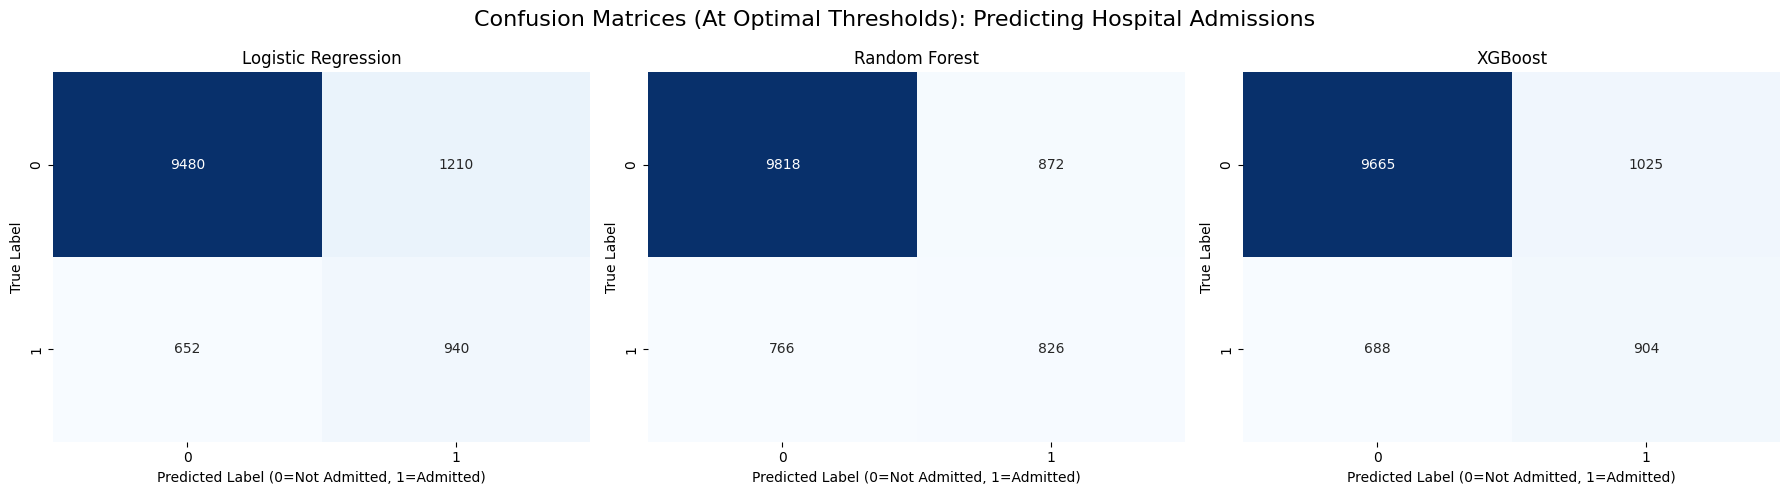

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices (At Optimal Thresholds): Predicting Hospital Admissions', fontsize=16)

models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted Label (0=Not Admitted, 1=Admitted)')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()



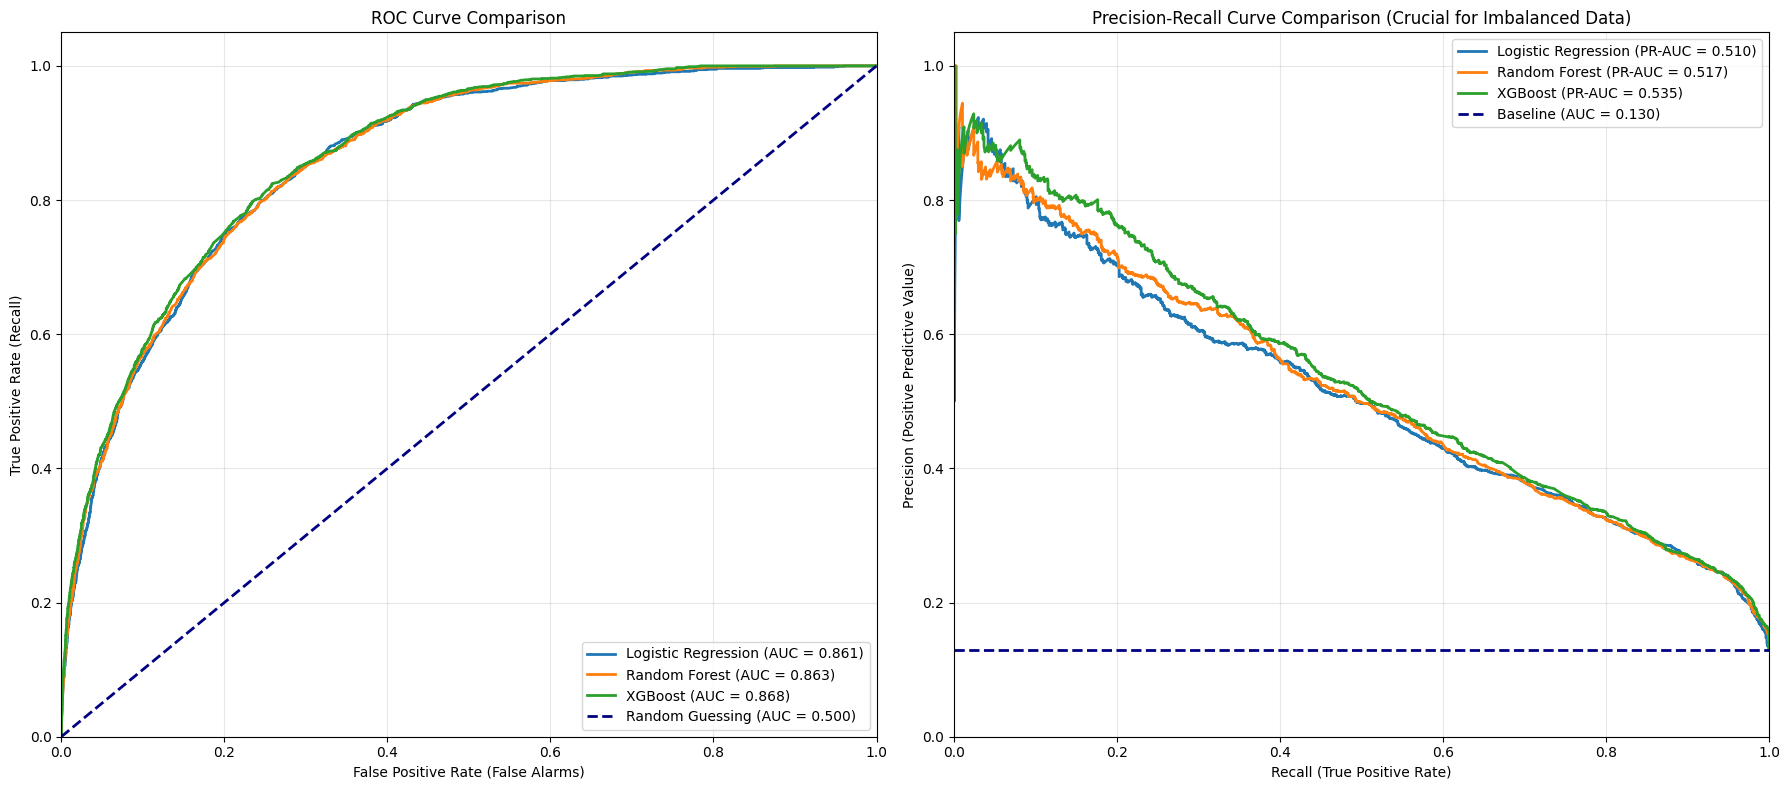

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

models_proba = [
    ('Logistic Regression', y_proba_lr),
    ('Random Forest', y_proba_rf),
    ('XGBoost', y_proba_xgb)
]

# --- Plot 1: ROC Curve ---
for name, y_proba in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (False Alarms)')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('ROC Curve Comparison')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- Plot 2: Precision-Recall Curve ---
for name, y_proba in models_proba:
    precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recalls, precisions)
    ax2.plot(recalls, precisions, lw=2, label=f'{name} (PR-AUC = {pr_auc:.3f})')

# Baseline for PR curve is the ratio of positive cases
baseline = y_test.sum() / len(y_test)
ax2.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Baseline (AUC = {baseline:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (True Positive Rate)')
ax2.set_ylabel('Precision (Positive Predictive Value)')
ax2.set_title('Precision-Recall Curve Comparison (Crucial for Imbalanced Data)')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



### Step 6: Persist Diagnostics to Disk
Saves the classification reports, confusion-matrix PNG and ROC-curve PNG to `machineLearning/plots/` (prefixes `01_`–`03_`) so the capstone report can embed them without re-running the notebook.

In [11]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("--- PHASE 4.5: SAVING METRICS TO DISK ---\n")

# 1. Define and create the plots directory
plots_dir = os.path.join(base_path, "machineLearning", "plots")
os.makedirs(plots_dir, exist_ok=True)
print(f"Directory ready: {plots_dir}")

# ==========================================
# 2. SAVE CLASSIFICATION REPORTS (TEXT FILE)
# ==========================================
report_path = os.path.join(plots_dir, "01_Admission_Classification_Reports.txt")
with open(report_path, "w") as f:
    f.write("--- LOGISTIC REGRESSION ---\n")
    f.write(classification_report(y_test, y_pred_lr))
    f.write("\n\n--- RANDOM FOREST ---\n")
    f.write(classification_report(y_test, y_pred_rf))
    f.write("\n\n--- XGBOOST ---\n")
    f.write(classification_report(y_test, y_pred_xgb))
print(f"✅ Saved text reports to: 01_Admission_Classification_Reports.txt")

# ==========================================
# 3. SAVE CONFUSION MATRICES (IMAGE)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices: Predicting PMCare Hospital Admissions', fontsize=16)

models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted Label (0=Not Admitted, 1=Admitted)')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
cm_path = os.path.join(plots_dir, "02_Admission_Confusion_Matrices.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight') # dpi=300 ensures print-quality resolution
plt.close() # Closes the plot so it doesn't double-print in the notebook
print(f"✅ Saved confusion matrices to: 02_Admission_Confusion_Matrices.png")

# ==========================================
# 4. SAVE ROC-AUC CURVE (IMAGE)
# ==========================================
plt.figure(figsize=(10, 8))

models_proba = [
    ('Logistic Regression', lr_model.predict_proba(X_test_final)[:, 1]),
    ('Random Forest', rf_model.predict_proba(X_test_final)[:, 1]),
    ('XGBoost', xgb_model.predict_proba(X_test_final)[:, 1])
]

for name, y_proba in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison: Diabetic Admission Risk')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

roc_path = os.path.join(plots_dir, "03_Admission_ROC_Curve.png")
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"✅ Saved ROC curve to: 03_Admission_ROC_Curve.png")

print("\n🎉 All evaluation assets successfully saved to disk!")

--- PHASE 4.5: SAVING METRICS TO DISK ---

Directory ready: C:\Users\thira\Documents\GitHub\project-d\machineLearning\plots
✅ Saved text reports to: 01_Admission_Classification_Reports.txt


✅ Saved confusion matrices to: 02_Admission_Confusion_Matrices.png


✅ Saved ROC curve to: 03_Admission_ROC_Curve.png

🎉 All evaluation assets successfully saved to disk!


### Step 7: Feature Importance (Tree-Based)
Plots XGBoost's native `feature_importances_` (gain-based) as a quick, model-faithful view of which features the champion actually splits on. SHAP in the next step gives the clinically-interpretable, signed version.

--- PHASE 5: MODEL INTERPRETABILITY (XGBOOST) ---



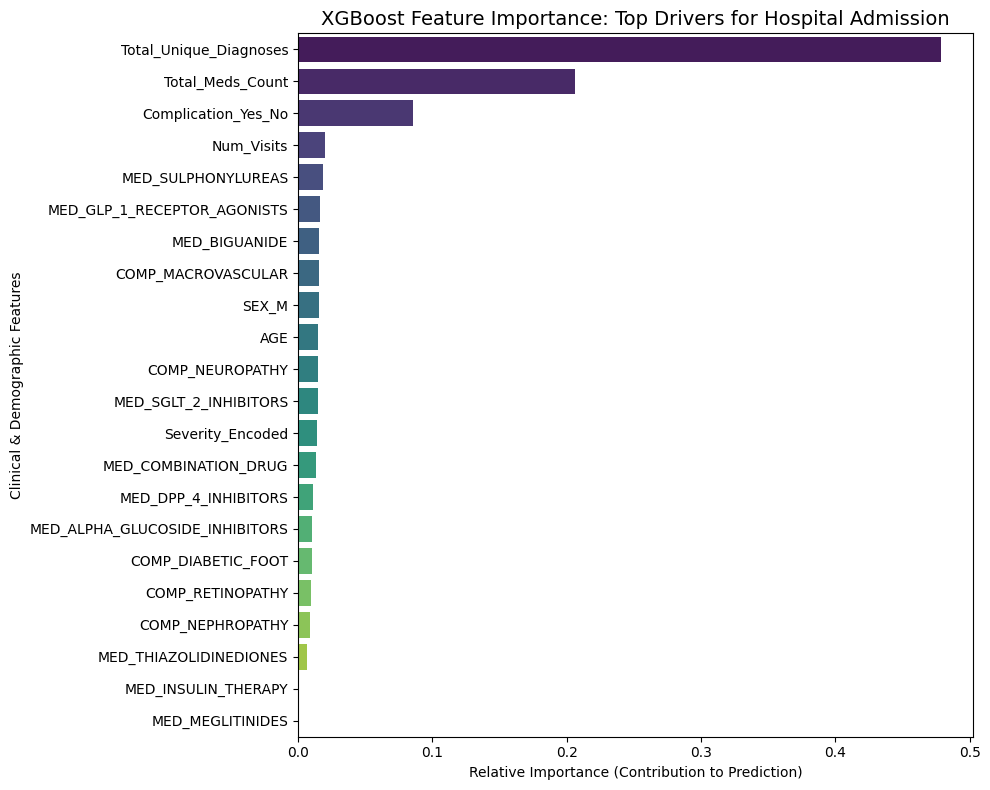

✅ Saved XGBoost Feature Importance plot to: C:\Users\thira\Documents\GitHub\project-d\machineLearning\plots\04_Admission_XGBoost_Importance.png

Top 5 Leading Indicators for PMCare Hospital Admissions:
               Feature  Importance
Total_Unique_Diagnoses    0.478911
      Total_Meds_Count    0.206443
   Complication_Yes_No    0.085399
            Num_Visits    0.019704
    MED_SULPHONYLUREAS    0.018223


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- PHASE 5: MODEL INTERPRETABILITY (XGBOOST) ---\n")

# 1. Extract the feature importance scores directly from the trained XGBoost model
xgb_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_importance, hue='Feature', palette='viridis', legend=False)
plt.title('XGBoost Feature Importance: Top Drivers for Hospital Admission', fontsize=14)
plt.xlabel('Relative Importance (Contribution to Prediction)')
plt.ylabel('Clinical & Demographic Features')
plt.tight_layout()

# 3. Save the plot to your plots folder
plots_dir = os.path.join(base_path, "machineLearning", "plots")
importance_path = os.path.join(plots_dir, "04_Admission_XGBoost_Importance.png")
plt.savefig(importance_path, dpi=300)
plt.show()

print(f"✅ Saved XGBoost Feature Importance plot to: {importance_path}\n")

print("Top 5 Leading Indicators for PMCare Hospital Admissions:")
print(xgb_importance.head(5).to_string(index=False))

### Step 8: Clinical Interpretability with SHAP (global + local)
`TreeExplainer` over the test set for the global beeswarm summary, plus a single-patient waterfall explanation for the first true-positive admission prediction. The global plot answers *what drives admission risk in general*; the waterfall answers *why was this patient flagged*.

C:\Users\thira\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- PHASE 6: SHAP VALUES FOR CLINICAL INTERPRETABILITY ---



1. GLOBAL DRIVERS: What pushes risk up or down across the entire hospital?


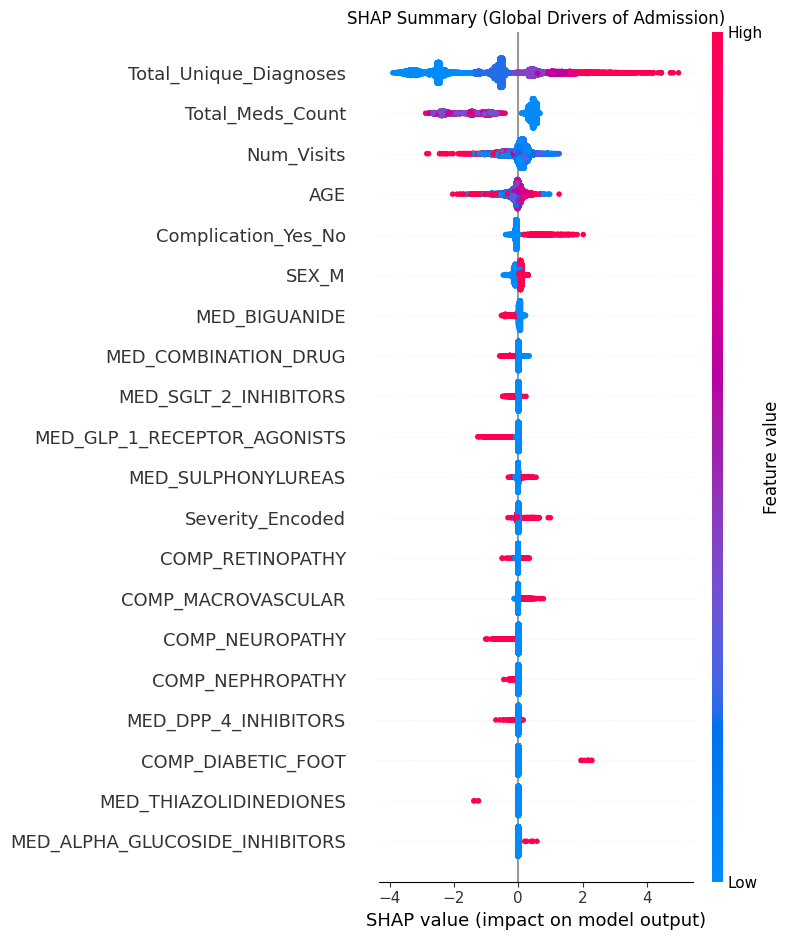


2. LOCAL EXPLANATION: Breaking down risk for a single patient.

Analyzing Patient Index: 3 (True Positive - Admitted)


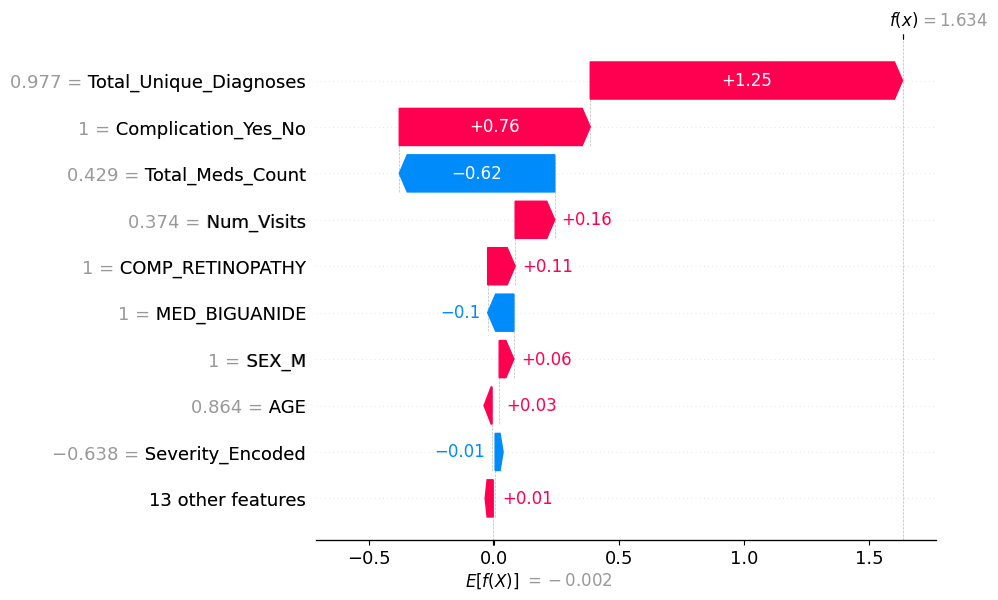

In [13]:
import shap

print("--- PHASE 6: SHAP VALUES FOR CLINICAL INTERPRETABILITY ---")

# Initialize the SHAP Explainer using the winning XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the Test Set (this can take a moment)
shap_values = explainer.shap_values(X_test_final)

# 1. Global Interpretability (Beeswarm Plot)
print("\n1. GLOBAL DRIVERS: What pushes risk up or down across the entire hospital?")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_final, show=False)
plt.title("SHAP Summary (Global Drivers of Admission)")
plt.tight_layout()
plt.show()

# 2. Local Interpretability (Individual Patient Explanations)
print("\n2. LOCAL EXPLANATION: Breaking down risk for a single patient.")

# Find a True Positive patient (Model correctly predicted an Admission)
true_positives = np.where((y_test.values == 1) & (y_pred_xgb == 1))[0]
patient_idx = true_positives[0] # Take the first one

print(f"\nAnalyzing Patient Index: {patient_idx} (True Positive - Admitted)")

# Generate Waterfall Plot for this specific patient
shap.plots.waterfall(shap.Explanation(values=shap_values[patient_idx], 
                                      base_values=explainer.expected_value, 
                                      data=X_test_final.iloc[patient_idx], 
                                      feature_names=X_test_final.columns))


### Step 9: Persist Artefacts for the Dashboard (canonical export)
This cell is the **single source of truth** for the admission model files consumed by `diabetesDashboard/scripts/build_export.py`. It writes the three trained classifiers, the fitted preprocessor, the *current* feature-name list (keeps the dashboard aligned with the notebook's feature count), a `thresholds.json` with the train-learned cut-offs from Step 4, and a refreshed `model_metadata.txt`. Running this cell replaces the previously-stale 14-feature artefacts and makes the dashboard predict from the model the notebook actually trained.

In [14]:
import joblib
import json
import os

print("--- PHASE 7: PERSISTING ADMISSION ARTEFACTS ---")

models_dir = os.path.join(base_path, "machineLearning", "models")
os.makedirs(models_dir, exist_ok=True)

# 1. Trained classifiers
joblib.dump(lr_model,  os.path.join(models_dir, "logistic_regression_admission.pkl"))
joblib.dump(rf_model,  os.path.join(models_dir, "random_forest_admission.pkl"))
joblib.dump(xgb_model, os.path.join(models_dir, "xgboost_admission.pkl"))

# 2. Fitted preprocessor (ColumnTransformer -> StandardScaler on continuous, passthrough on binary)
joblib.dump(preprocessor, os.path.join(models_dir, "standard_scaler.pkl"))

# 3. Feature-name list in the EXACT order the preprocessor expects (continuous first, then binary).
pd.DataFrame({"features": X_train_final.columns}).to_csv(
    os.path.join(models_dir, "feature_names.csv"), index=False
)

# 4. Train-learned thresholds for every admission model.
#    Track B (03_ML_Model_Readmission) appends to the same file, so we merge rather than overwrite.
thresholds_path = os.path.join(models_dir, "thresholds.json")
thresholds = {}
if os.path.exists(thresholds_path):
    try:
        with open(thresholds_path) as f:
            thresholds = json.load(f)
    except json.JSONDecodeError:
        thresholds = {}

thresholds.update({
    "lr_admission":  float(optimal_threshold_lr),
    "rf_admission":  float(optimal_threshold_rf),
    "xgb_admission": float(optimal_threshold_xgb),
})

with open(thresholds_path, "w") as f:
    json.dump(thresholds, f, indent=2)

# 5. Training provenance — reflects the CURRENT run, no more stale GridSearchCV/5-fold claim.
with open(os.path.join(models_dir, "model_metadata.txt"), "w") as f:
    f.write(f"Training Date: {pd.Timestamp.now()}\n")
    f.write(f"Training Set Size: {len(X_train_final)}\n")
    f.write(f"Test Set Size: {len(X_test_final)}\n")
    f.write(f"Number of Features: {X_train_final.shape[1]}\n")
    f.write(f"Target Variable: {target}\n")
    f.write(f"Class Imbalance Ratio: 1:{scale_weight:.2f}\n")
    f.write("Hyperparameter Tuning: GridSearchCV (LR) + RandomizedSearchCV n_iter=10 (RF, XGB), StratifiedKFold(3)\n")
    f.write(f"Learned Thresholds (admission): LR={optimal_threshold_lr:.4f} RF={optimal_threshold_rf:.4f} XGB={optimal_threshold_xgb:.4f}\n")

print(f"✅ Saved models, scaler, feature_names.csv ({X_train_final.shape[1]} features), thresholds.json, model_metadata.txt")
print(f"   → {models_dir}")

--- PHASE 7: PERSISTING ADMISSION ARTEFACTS ---
✅ Saved models, scaler, feature_names.csv (22 features), thresholds.json, model_metadata.txt
   → C:\Users\thira\Documents\GitHub\project-d\machineLearning\models
